# Numerical Analysis for Machine Learning
## PageRank Algorithm

**Academic Year:** 2025/2026  
**Professor:** Edie Miglio  
**Author:** Riccardo Infascelli (Codice Persona: 10742969, Matricola: 259426)

This notebook contains the Python implementation and the numerical experiments developed for the PageRank project. The mathematical formulation of the algorithm is discussed in the accompanying report.

The analysis starts from a basic implementation, then considers sparse matrices, convergence with respect to the damping factor, and applications to real networks.

## Setup and imports

In [1]:
import re
import time
from pathlib import Path
import tarfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx

from scipy.sparse import csr_matrix
from scipy.stats import spearmanr

SEED = 0
rng = np.random.default_rng(SEED)

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

## Basic PageRank implementation

We first implement PageRank directly from the iterative update formula.  
The graph is represented by a list of directed edges, where `(i, j)` means that node `i` links to node `j`.

At each iteration, the rank received through incoming links is combined with the rank redistributed from dangling nodes and with the teleportation term:

$$
x_i^{(k+1)}
=
\frac{1-\alpha}{n}
+
\alpha
\left(
\sum_{j \to i}
\frac{x_j^{(k)}}{\operatorname{outdeg}(j)}
+
\frac{\mathrm{sink\_mass}}{n}
\right).
$$

The iteration stops when the $L^1$ residual between two consecutive vectors is smaller than the prescribed tolerance.

In [2]:
def pagerank_basic(n, edges, alpha=0.85, max_iter=1000, tol=1e-8):
    """Compute PageRank from an edge list using explicit backlinks."""
    backlinks = [[] for _ in range(n)]
    out_degree = np.zeros(n, dtype=int)

    for i, j in edges:
        backlinks[j].append(i)
        out_degree[i] += 1

    rank = np.ones(n) / n
    residuals = []

    for _ in range(max_iter):
        sink_mass = rank[out_degree == 0].sum()

        new_rank = np.full(
            n,
            (1 - alpha) / n + alpha * sink_mass / n
        )

        for i in range(n):
            for j in backlinks[i]:
                new_rank[i] += alpha * rank[j] / out_degree[j]

        residual = np.linalg.norm(new_rank - rank, 1)
        residuals.append(residual)

        rank = new_rank

        if residual < tol:
            break

    return rank, residuals

## A first example from the literature

We first test the implementation on a six-page graph taken from Langville and Meyer. The graph includes a dangling node, making it a useful example for checking the complete PageRank update.


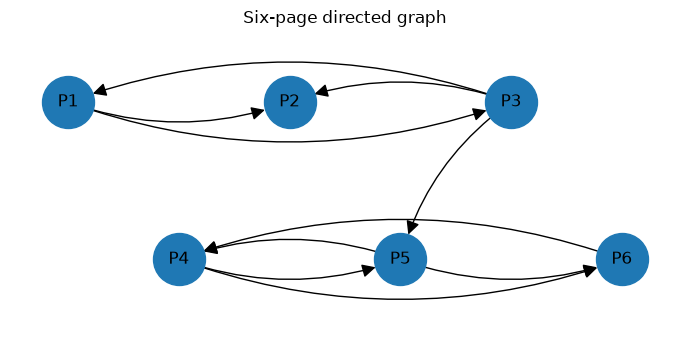

In [3]:
n = 6

edges = [
    (0, 1), (0, 2),
    (2, 0), (2, 1), (2, 4),
    (3, 4), (3, 5),
    (4, 3), (4, 5),
    (5, 3),
]

graph_example = nx.DiGraph()
graph_example.add_nodes_from(range(n))
graph_example.add_edges_from(edges)

positions = {
    0: (0.0, 1.0),
    1: (1.0, 1.0),
    2: (2.0, 1.0),
    3: (0.5, 0.0),
    4: (1.5, 0.0),
    5: (2.5, 0.0),
}

labels = {node: f"P{node + 1}" for node in graph_example.nodes}

plt.figure(figsize=(7, 3.5))

nx.draw_networkx(
    graph_example,
    pos=positions,
    labels=labels,
    node_size=1400,
    arrows=True,
    arrowsize=20,
    connectionstyle="arc3,rad=0.18",
)

plt.title("Six-page directed graph")
plt.axis("off")
plt.tight_layout()
plt.show()

### Why sink correction and teleportation are needed

Before applying the complete PageRank formula, we test what happens if the raw hyperlink iteration is used without dangling-node correction and without teleportation. This illustrates the numerical and probabilistic issues that motivate the Google matrix.

In [4]:
def raw_link_iteration(n, edges, max_iter=50):
    backlinks = [[] for _ in range(n)]
    out_degree = np.zeros(n, dtype=int)

    for i, j in edges:
        backlinks[j].append(i)
        out_degree[i] += 1

    rank = np.ones(n) / n
    sums = []

    for _ in range(max_iter):
        new_rank = np.zeros(n)

        for i in range(n):
            for j in backlinks[i]:
                new_rank[i] += rank[j] / out_degree[j]

        rank = new_rank
        sums.append(rank.sum())

    return rank, sums

In [5]:
raw_rank, raw_sums = raw_link_iteration(n, edges)

print("Final raw rank:", raw_rank)
print("Final sum:", raw_rank.sum())

Final raw rank: [5.86229258e-21 1.17245852e-20 5.86229258e-21 2.66666667e-01
 1.33333333e-01 2.00000000e-01]
Final sum: 0.6000000000000002


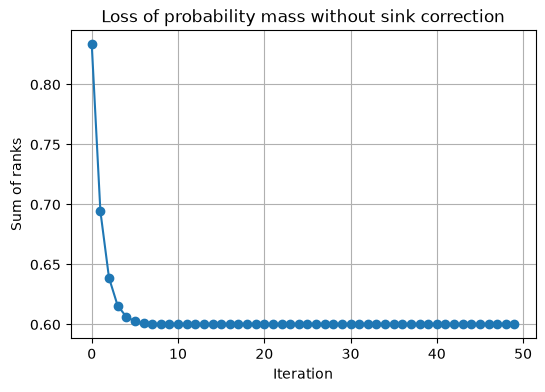

In [6]:
plt.figure(figsize=(6, 4))
plt.plot(raw_sums, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Sum of ranks")
plt.title("Loss of probability mass without sink correction")
plt.grid(True)
plt.show()

Without dangling-node correction, the raw hyperlink iteration does not preserve the total probability mass. Since page $P_2$ has no outgoing links, the rank that reaches this page is not redistributed to the graph. As a consequence, the sum of the PageRank vector decreases and the probabilistic interpretation is lost.

This motivates the use of the dangling-node correction and, together with teleportation, the construction of the Google matrix used in the complete PageRank algorithm.

### Complete PageRank computation on the six-page graph

In [7]:
rank_book, residuals_book = pagerank_basic(n, edges)

print("PageRank:", rank_book)
print("Sum:", rank_book.sum())
print("Iterations:", len(residuals_book))

PageRank: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
Sum: 1.0
Iterations: 33


The complete PageRank iteration preserves the probabilistic interpretation of the rank vector: the entries sum to one, unlike in the raw hyperlink iteration. The method converges in 33 iterations with the default parameters $\alpha = 0.85$ and $\mathrm{tol}=10^{-8}$.

The highest-ranked page is $P_4$, followed by $P_6$ and $P_5$. This is consistent with the structure of the graph, since these pages form the most strongly interconnected part of the network.

### Validation with the Google matrix eigenvector

To validate the result, we compare the iterative solution with the eigenvector of the Google matrix associated with the eigenvalue. Since the graph is very small, the matrix can be built explicitly for this test.

In [10]:
def google_matrix(n, edges, alpha=0.85):
    H = np.zeros((n, n))
    out_degree = np.zeros(n, dtype=int)

    for i, j in edges:
        out_degree[i] += 1

    for i, j in edges:
        H[i, j] = 1 / out_degree[i]

    H[out_degree == 0, :] = 1 / n

    return alpha * H + (1 - alpha) * np.ones((n, n)) / n


G = google_matrix(n, edges)

eigenvalues, eigenvectors = np.linalg.eig(G.T)
idx = np.argmin(np.abs(eigenvalues - 1))

rank_eig = np.real(eigenvectors[:, idx])
rank_eig /= rank_eig.sum()

print("Power iteration:", rank_book)
print("Eigensolver:    ", rank_eig)
print("L1 difference:  ", np.linalg.norm(rank_book - rank_eig, 1))

Power iteration: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
Eigensolver:     [0.05170475 0.07367926 0.05741241 0.34870369 0.19990381 0.26859608]
L1 difference:   8.537085829929403e-09


The power iteration and the direct eigensolver give the same PageRank vector up to the prescribed tolerance. The $L^1$ difference is approximately $8.5 \times 10^{-9}$, confirming the correctness of the implementation on this example.

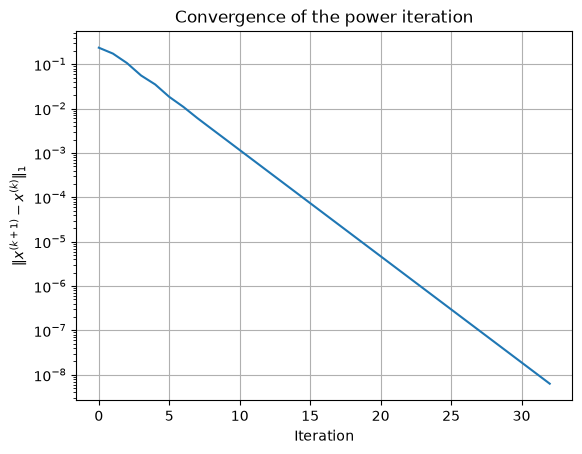

In [9]:
plt.semilogy(residuals_book)
plt.xlabel("Iteration")
plt.ylabel(r"$\|x^{(k+1)}-x^{(k)}\|_1$")
plt.title("Convergence of the power iteration")
plt.grid(True)
plt.show()

After a short initial phase, the residual decreases almost linearly on the logarithmic scale, showing the expected geometric convergence of the power iteration.

## Effect of the damping factor

We repeat the computation for different values of $\alpha$. A larger value gives more weight to the link structure and less to teleportation, but it is also expected to slow down the convergence.

In [18]:
alpha_values = [0.10, 0.50, 0.85, 0.95, 0.99]

rows = []
ranks_alpha = {}

for alpha in alpha_values:
    rank, residuals = pagerank_basic(n, edges, alpha=alpha)

    ranks_alpha[alpha] = rank

    rows.append({
        "alpha": alpha,
        "iterations": len(residuals),
        "final residual": residuals[-1]
    })

damping_results = pd.DataFrame(rows)
damping_results

,alpha,iterations,final residual
0,0.10,7,3.409946e-09
1,0.50,17,5.142719e-09
2,0.85,33,6.279296e-09
3,0.95,41,7.293612e-09
4,0.99,45,8.025144e-09


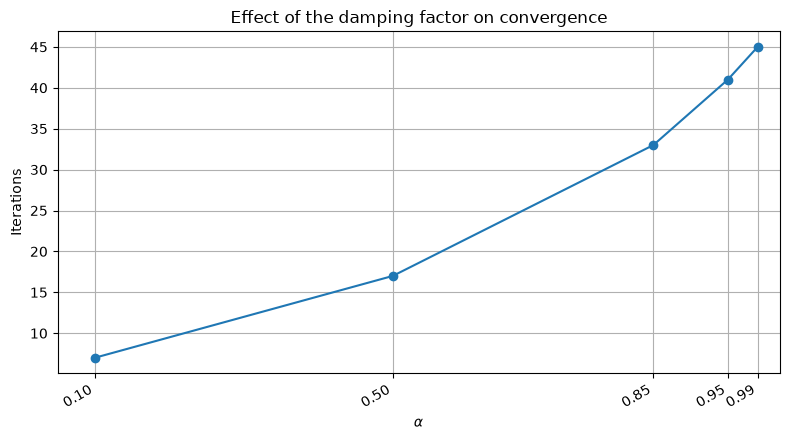

In [13]:
plt.figure(figsize=(8, 4.5))

plt.plot(
    damping_results["alpha"],
    damping_results["iterations"],
    marker="o"
)

plt.xlabel(r"$\alpha$")
plt.ylabel("Iterations")
plt.title("Effect of the damping factor on convergence")

plt.xticks(
    alpha_values,
    [f"{alpha:.2f}" for alpha in alpha_values],
    rotation=30,
    ha="right"
)

plt.xlim(0.05, 1.02)
plt.grid(True)
plt.tight_layout()
plt.show()

The number of iterations increases with $\alpha$. When teleportation is reduced, the convergence becomes more dependent on the link structure of the graph and is generally slower. In this example, the number of iterations increases from 7 for $\alpha=0.10$ to 45 for $\alpha=0.99$.

In [14]:
rank_comparison = pd.DataFrame(
    {f"alpha={alpha}": ranks_alpha[alpha] for alpha in alpha_values},
    index=[f"P{i}" for i in range(1, n + 1)]
)

rank_comparison

,alpha=0.1,alpha=0.5,alpha=0.85,alpha=0.95,alpha=0.99
P1,0.158123,0.116183,0.051705,0.020241,0.004359
P2,0.166029,0.145228,0.073679,0.029855,0.006516
P3,0.160673,0.124481,0.057412,0.022675,0.004899
P4,0.178121,0.239004,0.348704,0.406464,0.436222
P5,0.167029,0.175934,0.199904,0.213311,0.220289
P6,0.170025,0.199170,0.268596,0.307454,0.327715


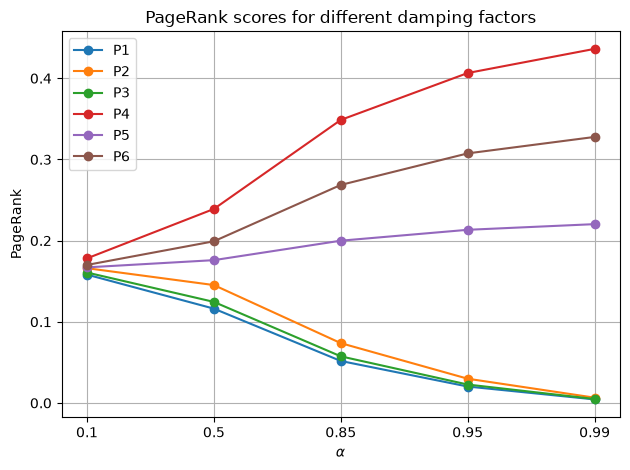

In [15]:
x = np.arange(len(alpha_values))

for page in rank_comparison.index:
    plt.plot(
        x,
        rank_comparison.loc[page],
        marker="o",
        label=page
    )

plt.xlabel(r"$\alpha$")
plt.ylabel("PageRank")
plt.title("PageRank scores for different damping factors")
plt.xticks(x, alpha_values)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The ordering of the pages remains unchanged for all the tested values of $\alpha$, but the PageRank scores become increasingly concentrated. For small $\alpha$, teleportation keeps the distribution close to uniform. As $\alpha$ approaches one, most of the rank accumulates in pages 4, 5 and 6, which form a closed group receiving an incoming link from the upper part of the graph.

### Convergence speed for different damping factors

In [20]:
alpha_values = [0.10, 0.50, 0.85, 0.95, 0.99]

results_alpha = {}

for alpha in alpha_values:
    rank_alpha, residuals_alpha = pagerank_basic(
        n,
        edges,
        alpha=alpha
    )

    results_alpha[alpha] = {
        "rank": rank_alpha,
        "residuals": residuals_alpha,
        "iterations": len(residuals_alpha)
    }

    print(f"alpha = {alpha:.2f}")
    print("PageRank:", np.round(rank_alpha, 6))
    print("Iterations:", len(residuals_alpha))
    print()

alpha = 0.10
PageRank: [0.158123 0.166029 0.160673 0.178121 0.167029 0.170025]
Iterations: 7

alpha = 0.50
PageRank: [0.116183 0.145228 0.124481 0.239004 0.175934 0.19917 ]
Iterations: 17

alpha = 0.85
PageRank: [0.051705 0.073679 0.057412 0.348704 0.199904 0.268596]
Iterations: 33

alpha = 0.95
PageRank: [0.020241 0.029855 0.022675 0.406464 0.213311 0.307454]
Iterations: 41

alpha = 0.99
PageRank: [0.004359 0.006516 0.004899 0.436222 0.220289 0.327715]
Iterations: 45



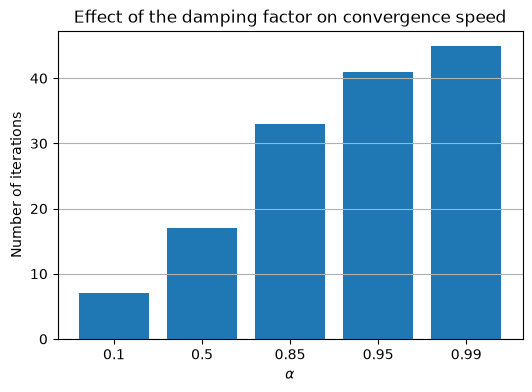

In [21]:
iterations = [
    results_alpha[alpha]["iterations"]
    for alpha in alpha_values
]

plt.figure(figsize=(6, 4))
plt.bar([str(alpha) for alpha in alpha_values], iterations)

plt.xlabel(r"$\alpha$")
plt.ylabel("Number of iterations")
plt.title("Effect of the damping factor on convergence speed")
plt.grid(axis="y")
plt.show()

The number of iterations increases as $\alpha$ becomes larger. This confirms that higher damping factors slow down the convergence of the power iteration, because the stabilizing effect of teleportation is reduced. Although the convergence speed changes, the ranking order remains unchanged in this small example.

## Sparse implementation

The basic implementation is already matrix-free, since it does not build the dense Google matrix explicitly. However, it relies on Python loops over backlinks, which become expensive when the number of edges increases. We therefore store the hyperlink matrix in sparse format and use matrix-vector products.

In [22]:
def build_sparse_matrix(n, edges):
    rows = np.array([i for i, j in edges])
    cols = np.array([j for i, j in edges])

    out_degree = np.bincount(rows, minlength=n)
    data = 1 / out_degree[rows]

    H = csr_matrix((data, (rows, cols)), shape=(n, n))
    dangling = out_degree == 0

    return H, dangling

In [23]:
def pagerank_sparse(H, dangling, alpha=0.85, max_iter=1000, tol=1e-8):
    n = H.shape[0]
    rank = np.ones(n) / n
    residuals = []

    for _ in range(max_iter):
        sink_mass = rank[dangling].sum()

        new_rank = (
            alpha * (H.T @ rank)
            + (alpha * sink_mass + 1 - alpha) / n
        )

        residual = np.linalg.norm(new_rank - rank, 1)
        residuals.append(residual)

        rank = new_rank

        if residual < tol:
            break

    return rank, residuals

In [24]:
H, dangling = build_sparse_matrix(n, edges)

rank_sparse, residuals_sparse = pagerank_sparse(H, dangling)

print("Basic implementation:", rank_book)
print("Sparse implementation:", rank_sparse)
print("L1 difference:", np.linalg.norm(rank_book - rank_sparse, 1))
print("Iterations:", len(residuals_sparse))

Basic implementation: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
Sparse implementation: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
L1 difference: 1.5265566588595902e-16
Iterations: 33


The basic and sparse implementations produce the same PageRank vector. The difference is at machine precision, confirming that the sparse formulation preserves the original iteration.

In [25]:
def random_graph(n, avg_degree=10):
    edges = []

    for i in range(n):
        targets = rng.choice(n, size=avg_degree, replace=False)
        edges.extend((i, int(j)) for j in targets if j != i)

    return edges

In [26]:
sizes = [100, 500, 1000, 5000]
repetitions = 5
rows = []

for n_test in sizes:
    edges_test = random_graph(n_test)

    basic_times = []
    sparse_times = []

    for _ in range(repetitions):
        start = time.perf_counter()
        rank_basic_test, _ = pagerank_basic(n_test, edges_test)
        basic_times.append(time.perf_counter() - start)

        start = time.perf_counter()
        H_test, dangling_test = build_sparse_matrix(n_test, edges_test)
        rank_sparse_test, _ = pagerank_sparse(H_test, dangling_test)
        sparse_times.append(time.perf_counter() - start)

    basic_time = np.median(basic_times)
    sparse_time = np.median(sparse_times)

    rows.append({
        "nodes": n_test,
        "edges": len(edges_test),
        "basic time": basic_time,
        "sparse time": sparse_time,
        "speedup": basic_time / sparse_time,
        "L1 difference": np.linalg.norm(
            rank_basic_test - rank_sparse_test, 1
        )
    })

performance_results = pd.DataFrame(rows)
performance_results

,nodes,edges,basic time,sparse time,speedup,L1 difference
0,100,990,0.005184,0.000663,7.823052,9.627715e-17
1,500,4995,0.016464,0.000786,20.954402,1.768334e-16
2,1000,9987,0.032552,0.001271,25.618369,1.759118e-16
3,5000,49983,0.175876,0.004706,37.371723,2.053343e-16


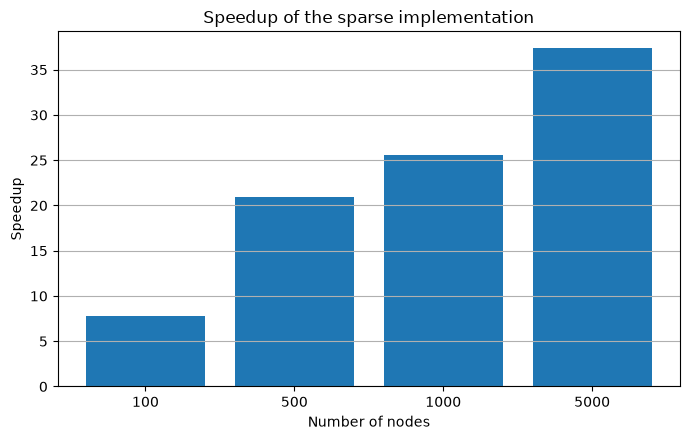

In [28]:
labels = performance_results["nodes"].astype(str)

plt.figure(figsize=(7, 4.5))

plt.bar(
    labels,
    performance_results["speedup"]
)

plt.xlabel("Number of nodes")
plt.ylabel("Speedup")
plt.title("Speedup of the sparse implementation")
plt.grid(axis="y")
plt.tight_layout()

plt.show()

The sparse implementation is faster for all tested graph sizes, and the speedup increases as the graph becomes larger. This shows the benefit of replacing explicit Python loops with sparse matrix-vector products.

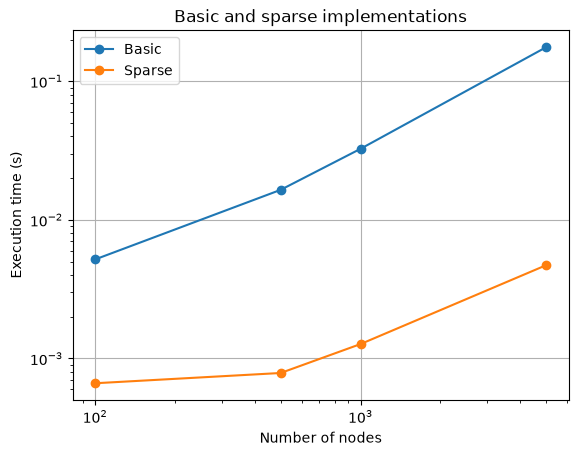

In [29]:
plt.loglog(
    performance_results["nodes"],
    performance_results["basic time"],
    marker="o",
    label="Basic"
)

plt.loglog(
    performance_results["nodes"],
    performance_results["sparse time"],
    marker="o",
    label="Sparse"
)

plt.xlabel("Number of nodes")
plt.ylabel("Execution time (s)")
plt.title("Basic and sparse implementations")
plt.legend()
plt.grid(True)
plt.show()

The log-log plot confirms the timing results: the sparse implementation is consistently faster than the basic one, and the gap increases for larger graphs.

The sparse implementation is consistently faster than the basic version, and the difference becomes more evident as the graph size increases. Both methods still produce the same PageRank vector up to machine precision.

## Linear system formulation

The PageRank vector can also be obtained by solving

$$
(I-\alpha S^T)x=(1-\alpha)v,
$$

where $S$ is the stochastic hyperlink matrix and $v$ is the uniform teleportation vector. On this small example, we compare the solution of the linear system with the result of the power iteration.

In [30]:
alpha = 0.85
v = np.ones(n) / n

S = H.toarray()
S[dangling, :] = 1 / n

A = np.eye(n) - alpha * S.T
b = (1 - alpha) * v

rank_linear = np.linalg.solve(A, b)
rank_linear /= rank_linear.sum()

print("Power iteration:", rank_sparse)
print("Linear system:  ", rank_linear)
print("L1 difference:  ", np.linalg.norm(rank_sparse - rank_linear, 1))

Power iteration: [0.05170475 0.07367926 0.05741241 0.34870368 0.19990381 0.26859608]
Linear system:   [0.05170475 0.07367926 0.05741241 0.34870369 0.19990381 0.26859608]
L1 difference:   8.537085226245633e-09


The linear system gives the same PageRank vector as the power iteration. The $L^1$ difference is approximately $8.5 \times 10^{-9}$, consistent with the stopping tolerance.

## Finding scientific gems

This experiment is inspired by the paper *Finding Scientific Gems with Google's PageRank Algorithm* by Chen, Xie, Maslov and Redner. The idea is to compare PageRank with the number of citations received by each paper.

In [31]:
EDGE_FILE = DATA_DIR / "cit-HepTh.txt.gz"

if not EDGE_FILE.exists():
    raise FileNotFoundError(
        f"Dataset not found: {EDGE_FILE}"
    )

edge_data = pd.read_csv(
    EDGE_FILE,
    sep=r"\s+",
    comment="#",
    names=["source", "target"],
    compression="gzip",
)

edge_data.head()

,source,target
0,1001,9304045
1,1001,9308122
2,1001,9309097
3,1001,9311042
4,1001,9401139


In [32]:
edge_data = (
    edge_data
    .drop_duplicates()
    .query("source != target")
    .reset_index(drop=True)
)

print("Number of citations:", len(edge_data))
edge_data.head()

Number of citations: 352768


,source,target
0,1001,9304045
1,1001,9308122
2,1001,9309097
3,1001,9311042
4,1001,9401139


In [33]:
node_ids = np.union1d(
    edge_data["source"].to_numpy(),
    edge_data["target"].to_numpy()
)

print("Number of papers:", len(node_ids))
print("Number of citations:", len(edge_data))

Number of papers: 27769
Number of citations: 352768


In [34]:
node_to_idx = {
    node_id: idx for idx, node_id in enumerate(node_ids)
}

sources = edge_data["source"].map(node_to_idx).to_numpy()
targets = edge_data["target"].map(node_to_idx).to_numpy()

n_nodes = len(node_ids)

In [36]:
out_degree = np.bincount(sources, minlength=n_nodes)
data = 1.0 / out_degree[sources]

H_cit = csr_matrix(
    (data, (sources, targets)),
    shape=(n_nodes, n_nodes)
)

dangling_cit = out_degree == 0

print("Dangling nodes:", dangling_cit.sum())

Dangling nodes: 2714


In [37]:
rank_cit, residuals_cit = pagerank_sparse(
    H_cit,
    dangling_cit,
    alpha=0.5,
    tol=1e-8
)

print("Sum:", rank_cit.sum())
print("Iterations:", len(residuals_cit))
print("Final residual:", residuals_cit[-1])

Sum: 1.0
Iterations: 20
Final residual: 5.590371530139613e-09


The PageRank vector is normalized and the iteration converges in 20 steps. We now compare PageRank with the number of citations received by each paper.

### Comparing PageRank with citation count

We now build a results table containing, for each paper, its PageRank score and its number of received citations. This allows us to compare structural importance with raw citation count.

In [38]:
citation_count = np.bincount(targets, minlength=n_nodes)

results = pd.DataFrame({
    "paper_id": node_ids,
    "pagerank": rank_cit,
    "citations": citation_count
})

results["pagerank_rank"] = (
    results["pagerank"]
    .rank(method="min", ascending=False)
    .astype(int)
)

results["citation_rank"] = (
    results["citations"]
    .rank(method="min", ascending=False)
    .astype(int)
)

results["rank_ratio"] = (
    results["citation_rank"] / results["pagerank_rank"]
)

results.sort_values("pagerank_rank").head(10)

,paper_id,pagerank,citations,pagerank_rank,citation_rank,rank_ratio
14158,9407087,0.002686,1299,1,4,4.000000
22152,9711200,0.002301,2414,2,1,0.500000
16725,9510017,0.001766,1155,3,6,2.000000
15602,9503124,0.001725,1114,4,8,2.000000
14349,9408099,0.001589,1006,5,10,2.000000
22742,9802150,0.001559,1775,6,2,0.333333
19154,9610043,0.001477,1199,7,5,0.714286
22708,9802109,0.001396,1641,8,3,0.375000
26166,9906064,0.001247,1032,9,9,1.000000
14723,9410167,0.001175,748,10,15,1.500000


In [39]:
rho, _ = spearmanr(
    results["pagerank"],
    results["citations"]
)

print("Spearman correlation:", rho)

Spearman correlation: 0.867897884452234


The Spearman correlation between PageRank and citation count is approximately $0.868$. The two rankings are therefore strongly related, although the correlation is not perfect. The differences between them may reveal papers whose importance is better captured by the citation network than by citation count alone.

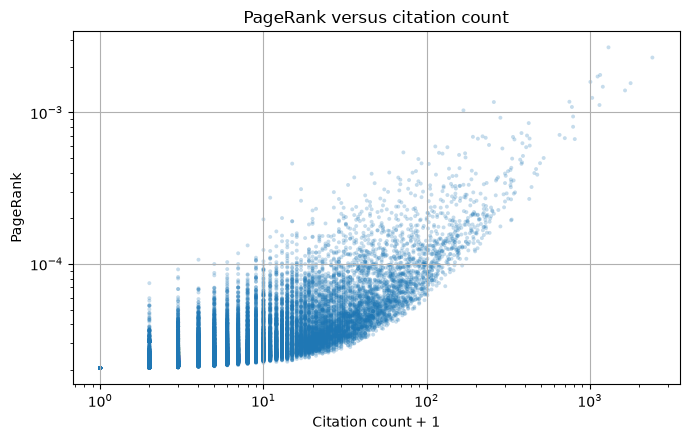

In [40]:
plt.figure(figsize=(7, 4.5))

plt.scatter(
    results["citations"] + 1,
    results["pagerank"],
    s=8,
    alpha=0.25,
    edgecolors="none"
)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Citation count + 1")
plt.ylabel("PageRank")
plt.title("PageRank versus citation count")

plt.grid(True, which="major")
plt.tight_layout()
plt.show()

The log-log scatter plot shows a clear positive association between PageRank and citation count. However, the dispersion indicates that papers with a similar number of citations can receive different PageRank scores, since the importance of the citing papers also matters.


## Top papers by PageRank

We first inspect the ten papers with the highest PageRank and compare their position with the ranking based on citation count.

In [41]:
top10_pagerank = (
    results
    .sort_values("pagerank_rank")
    .head(10)
    [[
        "paper_id",
        "pagerank",
        "pagerank_rank",
        "citations",
        "citation_rank",
        "rank_ratio"
    ]]
    .reset_index(drop=True)
)

top10_pagerank

,paper_id,pagerank,pagerank_rank,citations,citation_rank,rank_ratio
0,9407087,0.002686,1,1299,4,4.000000
1,9711200,0.002301,2,2414,1,0.500000
2,9510017,0.001766,3,1155,6,2.000000
3,9503124,0.001725,4,1114,8,2.000000
4,9408099,0.001589,5,1006,10,2.000000
5,9802150,0.001559,6,1775,2,0.333333
6,9610043,0.001477,7,1199,5,0.714286
7,9802109,0.001396,8,1641,3,0.375000
8,9906064,0.001247,9,1032,9,1.000000
9,9410167,0.001175,10,748,15,1.500000


The highest-ranked papers by PageRank also occupy high positions in the citation ranking. The two measures therefore largely agree at the top of the network, although the exact ordering is different.

In [42]:
gems = (
    results[
        (results["pagerank_rank"] <= 100)
        & (results["rank_ratio"] > 10)
    ]
    .sort_values("rank_ratio", ascending=False)
    [[
        "paper_id",
        "pagerank",
        "pagerank_rank",
        "citations",
        "citation_rank",
        "rank_ratio"
    ]]
    .reset_index(drop=True)
)

print("Number of candidate gems:", len(gems))
gems

Number of candidate gems: 13


,paper_id,pagerank,pagerank_rank,citations,citation_rank,rank_ratio
0,9201015,0.000459,52,14,5722,110.038462
1,9206047,0.000372,75,35,2187,29.160000
2,9208055,0.000332,97,32,2429,25.041237
3,9205037,0.000394,68,45,1546,22.735294
4,9204102,0.000544,38,71,781,20.552632
5,9402005,0.000401,63,58,1090,17.301587
6,9201059,0.000341,89,47,1450,16.292135
7,9205068,0.001031,14,167,174,12.428571
8,9202057,0.000492,47,88,558,11.872340
9,9206007,0.000371,76,66,890,11.710526


Among the first 100 papers by PageRank, 13 have a citation rank more than ten times worse than their PageRank rank. The most extreme case is paper 9201015, which is ranked 52nd by PageRank but only 5722nd by citation count. 

These papers can be considered candidate scientific gems, since their position in the citation network appears much more important than their raw number of citations suggests.

### Adding metadata to candidate papers

To make the candidate gems interpretable, we load the metadata associated with the papers. This allows us to recover information such as titles, authors, dates, and journal references.

In [43]:
METADATA_ARCHIVE = DATA_DIR / "cit-HepTh-abstracts.tar.gz"
METADATA_DIR = DATA_DIR / "hepth_metadata"

if not METADATA_ARCHIVE.exists():
    raise FileNotFoundError(
        f"Metadata archive not found: {METADATA_ARCHIVE}"
    )

METADATA_DIR.mkdir(exist_ok=True)

metadata_files = list(METADATA_DIR.rglob("*.abs"))

if not metadata_files:
    with tarfile.open(METADATA_ARCHIVE, "r:gz") as archive:
        archive.extractall(METADATA_DIR, filter="data")

    metadata_files = list(METADATA_DIR.rglob("*.abs"))

print("Metadata files:", len(metadata_files))

Metadata files: 29555


In [44]:
def parse_abs_file(path):
    lines = path.read_text(
        encoding="latin-1",
        errors="replace"
    ).splitlines()

    separators = [
        i for i, line in enumerate(lines)
        if line.strip() == r"\\"
    ]

    header_lines = lines[separators[0] + 1:separators[1]]

    fields = {}
    current_field = None

    for line in header_lines:
        match = re.match(
            r"^([A-Za-z][A-Za-z-]*):\s*(.*)$",
            line
        )

        if match:
            current_field = match.group(1).lower()
            fields[current_field] = match.group(2).strip()

        elif current_field is not None and line.strip():
            fields[current_field] += " " + line.strip()

    paper_match = re.search(
        r"(\d{7})",
        fields.get("paper", path.stem)
    )

    return {
        "paper_id": int(paper_match.group(1)),
        "title": fields.get("title"),
        "authors": fields.get("authors"),
        "date": fields.get("date"),
        "journal_ref": fields.get("journal-ref")
    }

In [45]:
records = [
    parse_abs_file(path)
    for path in metadata_files
]

metadata = (
    pd.DataFrame(records)
    .drop_duplicates("paper_id")
    .reset_index(drop=True)
)

print("Metadata records:", len(metadata))
print("Missing titles:", metadata["title"].isna().sum())

metadata.head()

Metadata records: 29555
Missing titles: 0


,paper_id,title,authors,date,journal_ref
0,9301112,On Integrable c<1 Open--Closed String Theory,Clifford V. Johnson,"Tue, 26 Jan 93 23:02:22 EST (24kb) Date (rev...",Nucl.Phys. B414 (1994) 239-266
1,9303063,Schwinger Effect in String Theory,C.Bachas,"Wed, 10 Mar 1993 14:07:49 +0100 (5kb) Date (...",NaN
2,9308136,Proof of Jacobi identity in generalized quantu...,"S.L. Adler, G.V. Bhanot, J.D. Weckel",27 Aug 1993 15:19:57 -0400 (EDT) (6kb),J.Math.Phys. 35 (1994) 531-535
3,9308122,"Mirror Symmetry, Mirror Map and Applications t...","S. Hosono, A. Klemm, S. Theisen","Thu, 26 Aug 93 14:09:47 SET (52kb) Date (rev...",Commun.Math.Phys. 167 (1995) 301-350
4,9303077,Abelian Anomalies in Nonlocal Regularization,"M. A. Clayton, L. Demopoulos, J. W. Moffat","Fri, 12 Mar 1993 11:43:32 -0500 (12kb)",Int. Journ. Mod. Phys. A9 (1994) Pg. 4549-4564


In [46]:
gems_with_metadata = gems.merge(
    metadata,
    on="paper_id",
    how="left"
)

pd.set_option("display.max_colwidth", 120)

gems_with_metadata[[
    "paper_id",
    "title",
    "authors",
    "pagerank_rank",
    "citations",
    "citation_rank",
    "rank_ratio"
]]

,paper_id,title,authors,pagerank_rank,citations,citation_rank,rank_ratio
0,9201015,An Algorithm to Generate Classical Solutions for String Effective Action,"S. Kar, S. Khastgir and A. Kumar",52,14,5722,110.038462
1,9206047,Addendum to ``Integrability of Open Spin Chains with Quantum Algebra Symmetry'',Luca Mezincescu and Rafael I. Nepomechie,75,35,2187,29.160000
2,9208055,Putting String/Fivebrane Duality to the Test,"J. A. Dixon, M. J. Duff and J. C. Plefka",97,32,2429,25.041237
3,9205037,Global Analysis of New Gravitational Singularities in String and Particle Theories,I. Bars and K. Sfetsos (USC),68,45,1546,22.735294
4,9204102,A New Supersymmetric Index,"Sergio Cecotti, Paul Fendley, Ken Intriligator and Cumrun Vafa",38,71,781,20.552632
5,9402005,Field Dependent Gauge Couplings in Locally Supersymmetric Effective Quantum Field Theories,V.Kaplunovsky and J.Louis,63,58,1090,17.301587
6,9201059,Quantum Hair on Black Holes,"Sidney Coleman, John Preskill, and Frank Wilczek",89,47,1450,16.292135
7,9205068,"ERRATA for ""One-Loop Threshold Effects in String Unification""",Vadim Kaplunovsky,14,167,174,12.428571
8,9202057,Exchange Operator Formalism for Integrable Systems of Particles,Alexios P. Polychronakos,47,88,558,11.872340
9,9206007,Chern-Simons Theory as the Large Mass Limit of Topologically Massive Yang-Mills Theory,"G. Giavarini, C.P. Martin, F. Ruiz Ruiz",76,66,890,11.710526


The analysis identifies 13 candidate scientific gems among the first 100 papers by PageRank. The strongest discrepancy is observed for *An Algorithm to Generate Classical Solutions for String Effective Action*, which is ranked 52nd by PageRank but only 5722nd by citation count.

These results show that PageRank can identify papers that occupy an important position in the citation network despite having relatively few citations. However, the presence of errata and addenda among the candidates also shows that a high structural importance does not necessarily imply a major scientific contribution. The selected papers should therefore be interpreted as candidates requiring further qualitative evaluation.

## Influence of publication year

We examine whether publication year affects PageRank. Older papers may have an advantage because they have had more time to accumulate citations and become connected to later influential work.

In [47]:
year_data = results.copy()

paper_code = (
    year_data["paper_id"]
    .astype(str)
    .str.zfill(7)
)

yy = paper_code.str[:2].astype(int)

year_data["year"] = np.where(
    yy >= 90,
    1900 + yy,
    2000 + yy
)

year_summary = (
    year_data
    .groupby("year")
    .agg(
        average_pagerank=("pagerank", "mean"),
        median_pagerank=("pagerank", "median"),
        publications=("paper_id", "size")
    )
    .reset_index()
)

year_summary

,year,average_pagerank,median_pagerank,publications
0,1992,0.000072,0.000045,1120
1,1993,0.000048,0.000031,1721
2,1994,0.000045,0.000028,2083
3,1995,0.000046,0.000029,2154
4,1996,0.000041,0.000028,2463
5,1997,0.000037,0.000027,2583
6,1998,0.000035,0.000026,2642
7,1999,0.000033,0.000025,2719
8,2000,0.000029,0.000025,3038
9,2001,0.000026,0.000023,3064


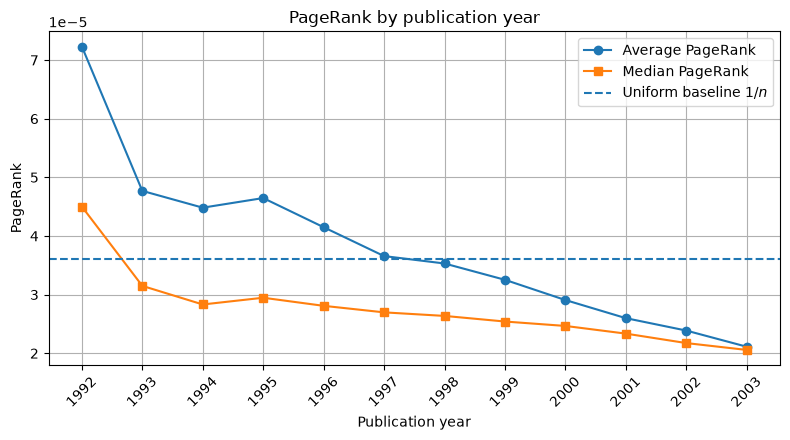

In [48]:
uniform_pagerank = 1 / len(year_data)

plt.figure(figsize=(8, 4.5))

plt.plot(
    year_summary["year"],
    year_summary["average_pagerank"],
    marker="o",
    label="Average PageRank"
)

plt.plot(
    year_summary["year"],
    year_summary["median_pagerank"],
    marker="s",
    label="Median PageRank"
)

plt.axhline(
    uniform_pagerank,
    linestyle="--",
    label=r"Uniform baseline $1/n$"
)

plt.xlabel("Publication year")
plt.ylabel("PageRank")
plt.title("PageRank by publication year")

plt.xticks(year_summary["year"], rotation=45)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

The average and median PageRank decrease with publication year, suggesting
an age advantage for older papers. These papers have had more time to
accumulate citations and to become connected to later influential works.
However, this trend should not be interpreted as an intrinsic bias of
PageRank, since it is also affected by the finite observation window of
the dataset, especially for the partially observed year 2003.

In [49]:
rho_year, p_year = spearmanr(
    year_data["year"],
    year_data["pagerank"]
)

print("Spearman correlation:", rho_year)
print("p-value:", p_year)

Spearman correlation: -0.3947554490626973
p-value: 0.0


The Spearman correlation between publication year and PageRank is
\(\rho_S=-0.395\), with \(p<10^{-16}\). This confirms a statistically
significant moderate negative association: more recent papers tend to
receive lower PageRank scores. The result is consistent with an age
advantage, but it does not establish an intrinsic bias of PageRank,
since older papers have had a longer citation window and the most
recent years are only partially observed.

## Sensitivity to the damping factor

We repeat the PageRank computation on the HEP-TH network for different values of $\alpha$. The ranking obtained with $\alpha=0.50$ is used as the reference for the Spearman correlations.

In [50]:
alpha_values = [0.10, 0.50, 0.85, 0.95]

ranks_real = {}
rows = []

for alpha in alpha_values:
    rank, residuals = pagerank_sparse(
        H_cit,
        dangling_cit,
        alpha=alpha,
        tol=1e-8
    )

    ranks_real[alpha] = rank

    rows.append({
        "alpha": alpha,
        "iterations": len(residuals),
        "final residual": residuals[-1]
    })

real_damping_results = pd.DataFrame(rows)
real_damping_results

,alpha,iterations,final residual
0,0.10,7,2.518493e-09
1,0.50,20,5.590372e-09
2,0.85,81,9.412540e-09
3,0.95,247,9.585554e-09


In [51]:
reference_rank = ranks_real[0.50]

correlations = []

for alpha in alpha_values:
    rho, _ = spearmanr(
        reference_rank,
        ranks_real[alpha]
    )

    correlations.append({
        "alpha": alpha,
        "Spearman with alpha=0.5": rho
    })

correlation_results = real_damping_results.merge(
    pd.DataFrame(correlations),
    on="alpha"
)

correlation_results

,alpha,iterations,final residual,Spearman with alpha=0.5
0,0.10,7,2.518493e-09,0.993961
1,0.50,20,5.590372e-09,1.000000
2,0.85,81,9.412540e-09,0.995629
3,0.95,247,9.585554e-09,0.992775


In [52]:
sensitivity_results = real_damping_results.merge(
    correlation_results[[
        "alpha",
        "Spearman with alpha=0.5"
    ]],
    on="alpha"
)

sensitivity_results.insert(
    0,
    "teleportation",
    1 - sensitivity_results["alpha"]
)
sensitivity_results

,teleportation,alpha,iterations,final residual,Spearman with alpha=0.5
0,0.90,0.10,7,2.518493e-09,0.993961
1,0.50,0.50,20,5.590372e-09,1.000000
2,0.15,0.85,81,9.412540e-09,0.995629
3,0.05,0.95,247,9.585554e-09,0.992775


The damping factor has a strong influence on the convergence rate. The number of iterations increases from 7 for $\alpha=0.10$ to 247 for $\alpha=0.95$, since larger values of $\alpha$ make the power iteration less contractive.

However, the rankings remain highly stable. The Spearman correlation with the reference ranking obtained for $\alpha=0.50$ is always greater than $0.992$. Therefore, the damping factor has a much stronger effect on convergence than on the global ordering of the papers.

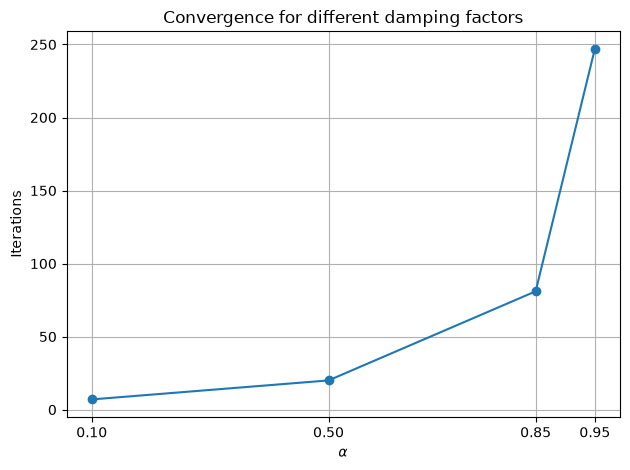

In [53]:
plt.plot(
    sensitivity_results["alpha"],
    sensitivity_results["iterations"],
    marker="o"
)

plt.xlabel(r"$\alpha$")
plt.ylabel("Iterations")
plt.title("Convergence for different damping factors")
plt.xticks(sensitivity_results["alpha"])
plt.grid(True)
plt.tight_layout()
plt.show()

The number of iterations grows rapidly as $\alpha$ approaches one. This behavior is consistent with the slower contraction of the PageRank iteration for larger damping factors.

## Dynamic PageRank update experiment

Real networks such as citation graphs and web graphs are dynamic: new nodes and new links are continuously added over time. Recomputing PageRank from scratch after every update may become inefficient when the graph is large.

In this experiment, we study a synthetic dynamic network. First, an old graph is generated. Then, a small set of new nodes and new links is added to obtain the updated graph. The goal is to compare different strategies for computing PageRank on the updated network: cold start, warm start, and aggregation-assisted refinement.

In [54]:
def pagerank_sparse_with_start(
    H,
    dangling,
    alpha=0.85,
    max_iter=1000,
    tol=1e-8,
    rank0=None
):
    n = H.shape[0]

    if rank0 is None:
        rank = np.ones(n) / n
    else:
        rank = np.asarray(rank0, dtype=float)
        rank = rank / rank.sum()

    residuals = []

    for _ in range(max_iter):
        sink_mass = rank[dangling].sum()

        new_rank = (
            alpha * (H.T @ rank + sink_mass / n)
            + (1 - alpha) / n
        )

        residual = np.linalg.norm(new_rank - rank, 1)
        residuals.append(residual)

        rank = new_rank

        if residual < tol:
            break

    return rank, residuals

### Building a synthetic dynamic network

We simulate a dynamic directed network in a controlled setting. The graph is built in two stages. First, an old network is generated. Then, a smaller set of new nodes is added to obtain the updated network.

The construction follows the intuition of a citation graph: each new node links only to nodes that already exist, so there are no links to future nodes. This makes the experiment suitable for testing dynamic PageRank strategies, because the updated graph keeps most of the old structure while adding a limited number of new nodes and links.

In the final experiment, the old graph contains 1,000,000 nodes and the update adds 10,000 new nodes.

In [92]:
def generate_synthetic_dynamic_graph(
    n_old,
    n_new,
    avg_degree=10,
    seed=0
):
    rng = np.random.default_rng(seed)

    old_sources = []
    old_targets = []

    for i in range(1, n_old):
        degree = min(avg_degree, i)

        targets = rng.choice(
            i,
            size=degree,
            replace=False
        )

        old_sources.extend([i] * degree)
        old_targets.extend(targets)

    full_sources = old_sources.copy()
    full_targets = old_targets.copy()

    n_full = n_old + n_new

    for i in range(n_old, n_full):
        targets = rng.choice(
            i,
            size=avg_degree,
            replace=False
        )

        full_sources.extend([i] * avg_degree)
        full_targets.extend(targets)

    return (
        np.array(old_sources),
        np.array(old_targets),
        np.array(full_sources),
        np.array(full_targets)
    )


def build_sparse_from_arrays(n, sources, targets):
    out_degree = np.bincount(sources, minlength=n)
    data = 1.0 / out_degree[sources]

    H = csr_matrix(
        (data, (sources, targets)),
        shape=(n, n)
    )

    dangling = out_degree == 0

    return H, dangling

In [93]:
n_old = 1000000
n_new = 10000
avg_degree_synth = 10

alpha_update = 0.85
tol_update = 1e-8

(
    old_sources_synth,
    old_targets_synth,
    full_sources_synth,
    full_targets_synth
) = generate_synthetic_dynamic_graph(
    n_old=n_old,
    n_new=n_new,
    avg_degree=avg_degree_synth,
    seed=SEED
)

n_nodes = n_old + n_new

H_old, dangling_old = build_sparse_from_arrays(
    n_old,
    old_sources_synth,
    old_targets_synth
)

H_update, dangling_update = build_sparse_from_arrays(
    n_nodes,
    full_sources_synth,
    full_targets_synth
)

old_full_indices = np.arange(n_old)

is_old_node = np.zeros(n_nodes, dtype=bool)
is_old_node[old_full_indices] = True

is_new_node = ~is_old_node
n_new_nodes = is_new_node.sum()

print("Old synthetic nodes:", n_old)
print("Full synthetic nodes:", n_nodes)
print("Old synthetic edges:", len(old_sources_synth))
print("Full synthetic edges:", len(full_sources_synth))
print("New nodes added:", n_new_nodes)
print("New edges added:", len(full_sources_synth) - len(old_sources_synth))

Old synthetic nodes: 1000000
Full synthetic nodes: 1010000
Old synthetic edges: 9999945
Full synthetic edges: 10099945
New nodes added: 10000
New edges added: 100000


In [94]:
start = time.perf_counter()

rank_old, residuals_old = pagerank_sparse_with_start(
    H_old,
    dangling_old,
    alpha=alpha_update,
    tol=tol_update
)

old_time = time.perf_counter() - start

rank0_warm = np.zeros(n_nodes)

old_mass = n_old / n_nodes
new_mass = 1 - old_mass

rank0_warm[old_full_indices] = old_mass * rank_old

if n_new_nodes > 0:
    rank0_warm[is_new_node] = new_mass / n_new_nodes

rank0_warm = rank0_warm / rank0_warm.sum()

print("Old PageRank iterations:", len(residuals_old))
print("Old PageRank time:", old_time)
print("Warm-start vector sum:", rank0_warm.sum())
print("New nodes:", n_new_nodes)

Old PageRank iterations: 73
Old PageRank time: 1.299255499994615
Warm-start vector sum: 1.0
New nodes: 10000


### Cold start versus warm start

We first compare two exact PageRank computations on the full updated graph. In the cold-start approach, the power iteration starts from the uniform distribution. In the warm-start approach, the iteration starts from the PageRank vector previously computed on the old graph, extended to the new nodes.

The warm start does not change the PageRank model or the final solution. It only provides a better initial vector for the power iteration on the updated graph.

In [95]:
start = time.perf_counter()

rank_cold, residuals_cold = pagerank_sparse_with_start(
    H_update,
    dangling_update,
    alpha=alpha_update,
    tol=tol_update
)

cold_time = time.perf_counter() - start


start = time.perf_counter()

rank_warm, residuals_warm = pagerank_sparse_with_start(
    H_update,
    dangling_update,
    alpha=alpha_update,
    tol=tol_update,
    rank0=rank0_warm
)

warm_time = time.perf_counter() - start


dynamic_update_results = pd.DataFrame([
    {
        "method": "cold start",
        "iterations": len(residuals_cold),
        "time": cold_time,
        "final residual": residuals_cold[-1]
    },
    {
        "method": "warm start",
        "iterations": len(residuals_warm),
        "time": warm_time,
        "final residual": residuals_warm[-1]
    }
])

dynamic_update_results["L1 difference from cold"] = [
    0.0,
    np.linalg.norm(rank_warm - rank_cold, 1)
]

dynamic_update_results

,method,iterations,time,final residual,L1 difference from cold
0,cold start,73,1.262200,9.675006e-09,0.000000e+00
1,warm start,55,0.906911,8.220578e-09,2.430321e-08


The warm start improves the convergence with respect to the cold start. On the updated graph, the cold-start computation requires 73 iterations and 1.262 seconds, while the warm-start computation requires 55 iterations and 0.907 seconds.

Both methods converge to essentially the same PageRank vector, as shown by the very small $L^1$ difference. This confirms that the warm start improves the initialization without changing the final PageRank solution.

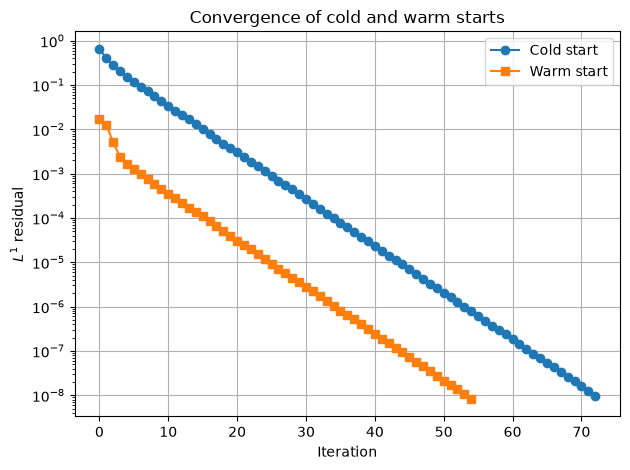

In [96]:
plt.semilogy(
    residuals_cold,
    marker="o",
    label="Cold start"
)

plt.semilogy(
    residuals_warm,
    marker="s",
    label="Warm start"
)

plt.xlabel("Iteration")
plt.ylabel(r"$L^1$ residual")
plt.title("Convergence of cold and warm starts")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

The residual plot confirms that the warm-start iteration begins closer to the final PageRank vector. As a result, it reaches the stopping tolerance in fewer iterations than the cold-start method.

### Selecting the explicit set for aggregation

To build an aggregation-based initialization, we keep only part of the graph explicitly represented. The explicit set contains all new nodes and the most important old nodes according to the old PageRank vector.

All remaining old nodes are compressed into a single aggregate node. This keeps the reduced problem small while preserving the most relevant part of the old graph.

In [97]:
n_top_old = 500

top_old_local_indices = np.argsort(rank_old)[-n_top_old:]
top_old_full_indices = old_full_indices[top_old_local_indices]

explicit_mask = is_new_node.copy()
explicit_mask[top_old_full_indices] = True

explicit_nodes = np.where(explicit_mask)[0]
aggregate_nodes = np.where(~explicit_mask)[0]

print("Explicit nodes:", len(explicit_nodes))
print("Aggregated nodes:", len(aggregate_nodes))
print("Full network nodes:", n_nodes)
print("Reduced problem size:", len(explicit_nodes) + 1)

Explicit nodes: 10500
Aggregated nodes: 999500
Full network nodes: 1010000
Reduced problem size: 10501


### PageRank with non-uniform teleportation

In the reduced network, one aggregate node represents many original papers. Therefore, teleportation should not be uniform over the reduced nodes: the aggregate node must receive a probability proportional to the number of papers it represents.

We use a slightly more general PageRank routine, where the teleportation vector can be non-uniform and rows with missing probability mass are treated as dangling mass.

In [98]:
def pagerank_substochastic(
    H,
    teleportation,
    alpha=0.85,
    max_iter=1000,
    tol=1e-8,
    rank0=None
):
    n = H.shape[0]

    v = np.asarray(teleportation, dtype=float)
    v = v / v.sum()

    row_sums = np.asarray(H.sum(axis=1)).ravel()
    missing_mass = np.clip(1 - row_sums, 0, 1)

    if rank0 is None:
        rank = v.copy()
    else:
        rank = np.asarray(rank0, dtype=float)
        rank = rank / rank.sum()

    residuals = []

    for _ in range(max_iter):
        dangling_mass = rank @ missing_mass

        new_rank = (
            alpha * (H.T @ rank + dangling_mass * v)
            + (1 - alpha) * v
        )

        residual = np.linalg.norm(new_rank - rank, 1)
        residuals.append(residual)

        rank = new_rank

        if residual < tol:
            break

    return rank, residuals

### Aggregated approximation

The reduced graph is used to compute an approximate PageRank vector. This approximation is not considered as a final result in the comparison, because it is not obtained by solving the full PageRank problem.

Instead, it is used as an informed initial vector for a refinement step on the full updated graph.

In [99]:
k = len(explicit_nodes)
aggregate_index = k

full_to_reduced = np.full(n_nodes, aggregate_index, dtype=int)
full_to_reduced[explicit_nodes] = np.arange(k)

aggregate_weights = rank0_warm[aggregate_nodes]

if aggregate_weights.sum() > 0:
    aggregate_weights = aggregate_weights / aggregate_weights.sum()
else:
    aggregate_weights = np.ones(len(aggregate_nodes)) / len(aggregate_nodes)

node_weights = np.ones(n_nodes)
node_weights[aggregate_nodes] = aggregate_weights

H_coo = H_update.tocoo()

reduced_rows = full_to_reduced[H_coo.row]
reduced_cols = full_to_reduced[H_coo.col]
reduced_data = H_coo.data.copy()

is_aggregate_row = ~explicit_mask[H_coo.row]
reduced_data[is_aggregate_row] *= node_weights[H_coo.row[is_aggregate_row]]

H_reduced = csr_matrix(
    (reduced_data, (reduced_rows, reduced_cols)),
    shape=(k + 1, k + 1)
)

teleportation_reduced = np.full(k + 1, 1 / n_nodes)
teleportation_reduced[aggregate_index] = len(aggregate_nodes) / n_nodes
teleportation_reduced = teleportation_reduced / teleportation_reduced.sum()

print("Reduced matrix shape:", H_reduced.shape)
print("Reduced nonzeros:", H_reduced.nnz)
print("Teleportation sum:", teleportation_reduced.sum())
print("Aggregate teleportation mass:", teleportation_reduced[aggregate_index])

Reduced matrix shape: (10501, 10501)
Reduced nonzeros: 15970
Teleportation sum: 1.0
Aggregate teleportation mass: 0.9896039603960396


The reduced problem is much smaller than the full updated graph. While the full graph has more than one million nodes, the aggregated problem contains only 10,501 nodes.

The teleportation vector assigns most of the probability mass to the aggregate node, because this node represents the large set of old nodes that are not kept explicitly.

In [100]:
start = time.perf_counter()

rank_reduced, residuals_reduced = pagerank_substochastic(
    H_reduced,
    teleportation_reduced,
    alpha=alpha_update,
    tol=tol_update
)

reduced_time = time.perf_counter() - start

rank_aggregated = np.zeros(n_nodes)

rank_aggregated[explicit_nodes] = rank_reduced[:k]

aggregate_mass = rank_reduced[aggregate_index]
rank_aggregated[aggregate_nodes] = aggregate_mass * aggregate_weights

rank_aggregated = rank_aggregated / rank_aggregated.sum()

print("Reduced PageRank iterations:", len(residuals_reduced))
print("Reduced PageRank time:", reduced_time)
print("Approximate PageRank sum:", rank_aggregated.sum())
print("Aggregate PageRank mass:", aggregate_mass)

Reduced PageRank iterations: 37
Reduced PageRank time: 0.010734207993664313
Approximate PageRank sum: 0.9999999999999999
Aggregate PageRank mass: 0.764975089010868


The aggregated PageRank vector is only an approximation of the full PageRank solution. However, it provides an informed estimate of the importance distribution on the updated graph.

For this reason, we do not use it as a final result. Instead, we use it as the initial vector for a refinement step on the full graph.

### Accuracy of the aggregated initialization

The aggregated computation solves a much smaller PageRank problem, so it is much faster than a full PageRank computation. However, it only provides an approximation of the PageRank vector on the complete updated graph.

For this reason, we use it only as an initialization for the refinement step, not as a final PageRank result.

In [101]:
rho_agg, _ = spearmanr(
    rank_cold,
    rank_aggregated
)

top_k = 100

top_exact = set(
    np.argsort(rank_cold)[-top_k:]
)

top_aggregated = set(
    np.argsort(rank_aggregated)[-top_k:]
)

top_overlap = len(top_exact & top_aggregated) / top_k

aggregation_comparison = pd.DataFrame([
    {
        "method": "cold start exact",
        "problem size": n_nodes,
        "iterations": len(residuals_cold),
        "time": cold_time,
        "L1 difference from exact": 0.0,
        "Spearman with exact": 1.0,
        "top 100 overlap": 1.0
    },
    {
        "method": "warm start exact",
        "problem size": n_nodes,
        "iterations": len(residuals_warm),
        "time": warm_time,
        "L1 difference from exact": np.linalg.norm(rank_warm - rank_cold, 1),
        "Spearman with exact": spearmanr(rank_cold, rank_warm)[0],
        "top 100 overlap": len(
            set(np.argsort(rank_warm)[-top_k:]) & top_exact
        ) / top_k
    },
    {
        "method": "approximate aggregation",
        "problem size": H_reduced.shape[0],
        "iterations": len(residuals_reduced),
        "time": reduced_time,
        "L1 difference from exact": np.linalg.norm(rank_aggregated - rank_cold, 1),
        "Spearman with exact": rho_agg,
        "top 100 overlap": top_overlap
    }
])

aggregation_comparison

,method,problem size,iterations,time,L1 difference from exact,Spearman with exact,top 100 overlap
0,cold start exact,1010000,73,1.262200,0.000000e+00,1.000000,1.0
1,warm start exact,1010000,55,0.906911,2.430321e-08,1.000000,1.0
2,approximate aggregation,10501,37,0.010734,2.794019e-03,0.999018,1.0


The aggregated approximation is close to the exact ranking, but it is not itself the final result. The important point is that it provides a strong initial guess for the full PageRank iteration.

After refinement, the method converges to the same ranking as the cold-start computation, but with many fewer full-graph iterations.

### Aggregation-assisted refinement

The aggregated approximation is now used as the starting vector for a standard PageRank iteration on the full updated graph.

This refinement step computes the PageRank vector on the complete graph, but it starts from a much better initialization than the uniform distribution.

In [102]:
start = time.perf_counter()

rank_refined, residuals_refined = pagerank_sparse_with_start(
    H_update,
    dangling_update,
    alpha=alpha_update,
    tol=tol_update,
    rank0=rank_aggregated
)

refinement_time = time.perf_counter() - start

total_aggregation_refinement_time = reduced_time + refinement_time

rho_refined, _ = spearmanr(
    rank_cold,
    rank_refined
)

refined_top_overlap = len(
    set(np.argsort(rank_refined)[-top_k:]) & top_exact
) / top_k

refinement_results = pd.DataFrame([
    {
        "method": "cold start exact",
        "problem size": n_nodes,
        "iterations": len(residuals_cold),
        "time": cold_time,
        "total time": cold_time,
        "L1 difference from exact": 0.0,
        "Spearman with exact": 1.0,
        "top 100 overlap": 1.0
    },
    {
        "method": "warm start exact",
        "problem size": n_nodes,
        "iterations": len(residuals_warm),
        "time": warm_time,
        "total time": warm_time,
        "L1 difference from exact": np.linalg.norm(rank_warm - rank_cold, 1),
        "Spearman with exact": spearmanr(rank_cold, rank_warm)[0],
        "top 100 overlap": len(
            set(np.argsort(rank_warm)[-top_k:]) & top_exact
        ) / top_k
    },
    {
        "method": "approximate aggregation",
        "problem size": H_reduced.shape[0],
        "iterations": len(residuals_reduced),
        "time": reduced_time,
        "total time": reduced_time,
        "L1 difference from exact": np.linalg.norm(rank_aggregated - rank_cold, 1),
        "Spearman with exact": rho_agg,
        "top 100 overlap": top_overlap
    },
    {
        "method": "aggregation + refinement",
        "problem size": n_nodes,
        "iterations": len(residuals_refined),
        "time": refinement_time,
        "total time": total_aggregation_refinement_time,
        "L1 difference from exact": np.linalg.norm(rank_refined - rank_cold, 1),
        "Spearman with exact": rho_refined,
        "top 100 overlap": refined_top_overlap
    }
])

refinement_results

,method,problem size,iterations,time,total time,L1 difference from exact,Spearman with exact,top 100 overlap
0,cold start exact,1010000,73,1.262200,1.262200,0.000000e+00,1.000000,1.0
1,warm start exact,1010000,55,0.906911,0.906911,2.430321e-08,1.000000,1.0
2,approximate aggregation,10501,37,0.010734,0.010734,2.794019e-03,0.999018,1.0
3,aggregation + refinement,1010000,23,0.397177,0.407911,2.870358e-08,1.000000,1.0


### Final comparison of exact update methods

In the final comparison, we only report methods that compute PageRank on the full updated graph. The approximate aggregation step is used internally to initialize the refinement phase.

In [106]:
speedup_results = refinement_results[
    refinement_results["method"] != "approximate aggregation"
].copy()

cold_total_time = speedup_results.loc[
    speedup_results["method"] == "cold start exact",
    "total time"
].iloc[0]

warm_total_time = speedup_results.loc[
    speedup_results["method"] == "warm start exact",
    "total time"
].iloc[0]

speedup_results["speedup vs cold"] = (
    cold_total_time / speedup_results["total time"]
)

speedup_results["speedup vs warm"] = (
    warm_total_time / speedup_results["total time"]
)

speedup_results = speedup_results[
    [
        "method",
        "problem size",
        "iterations",
        "total time",
        "L1 difference from exact",
        "Spearman with exact",
        "top 100 overlap",
        "speedup vs cold",
        "speedup vs warm"
    ]
]

speedup_results

,method,problem size,iterations,total time,L1 difference from exact,Spearman with exact,top 100 overlap,speedup vs cold,speedup vs warm
0,cold start exact,1010000,73,1.262200,0.000000e+00,1.0,1.0,1.000000,0.718516
1,warm start exact,1010000,55,0.906911,2.430321e-08,1.0,1.0,1.391757,1.000000
3,aggregation + refinement,1010000,23,0.407911,2.870358e-08,1.0,1.0,3.094301,2.223305


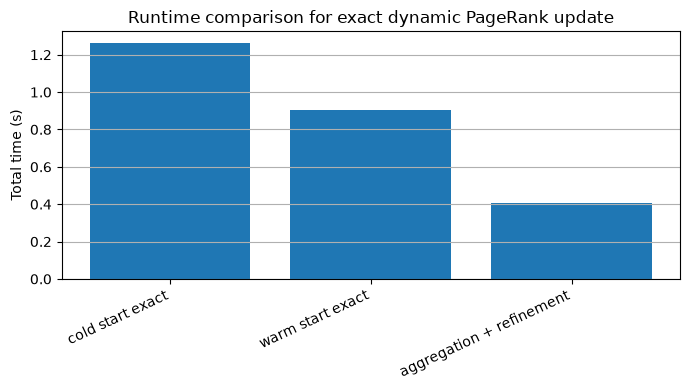

In [107]:
plt.figure(figsize=(7, 4))

plt.bar(
    speedup_results["method"],
    speedup_results["total time"]
)

plt.ylabel("Total time (s)")
plt.title("Runtime comparison for exact dynamic PageRank update")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

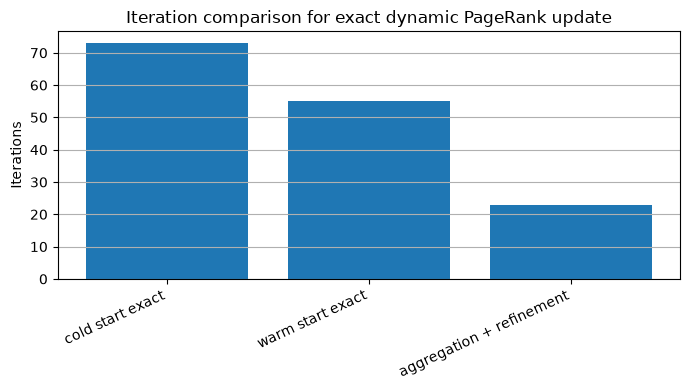

In [108]:
plt.figure(figsize=(7, 4))

plt.bar(
    speedup_results["method"],
    speedup_results["iterations"]
)

plt.ylabel("Iterations")
plt.title("Iteration comparison for exact dynamic PageRank update")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

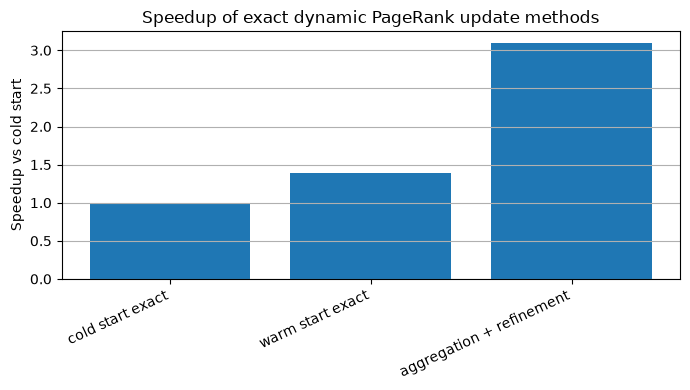

In [109]:
plt.figure(figsize=(7, 4))

plt.bar(
    speedup_results["method"],
    speedup_results["speedup vs cold"]
)

plt.ylabel("Speedup vs cold start")
plt.title("Speedup of update methods")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

For the final comparison, we report only methods that compute PageRank on the full updated graph. The aggregated approximation is not treated as a final method; it is used only to initialize the refinement phase.

The updated graph contains 1,010,000 nodes. Cold start requires 73 iterations and 1.262 seconds, while warm start reduces the cost to 55 iterations and 0.907 seconds.

Aggregation-assisted refinement gives the best exact performance. It converges in 23 iterations, with a total time of 0.408 seconds. This corresponds to a speedup of about 3.1 over cold start and 2.2 over warm start. The $L^1$ difference is negligible, and both the Spearman correlation and the top-100 overlap are equal to 1, confirming that the same ranking is recovered.